In [37]:
# Importlar
import os
import time
import tempfile
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

warnings.filterwarnings("ignore")

# Tekrarlanabilirlik
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
print("Importlar tamamlandi.")

Importlar tamamlandi.


In [38]:
# --- KONFIGURASYON (EfficientNetV2) ---
MODEL_NAME = 'tf_efficientnetv2_m'
EXPERIMENT_NAME = "EfficientNetV2_Medium_Baseline_MediumLarge_Run1"

# Hiperparametreler (iyilestirilmis ayar)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1.5e-4
NUM_CLASSES = 8
DROPOUT_RATE = 0.3
DROP_PATH_RATE = 0.15

# Hiz / egitim davranisi
USE_AMP = True
LOG_EVERY_N_STEPS = 10

# Veri ayari
USE_TRAIN_AUG = False

# Duzenlilestirme ve egitim kararliligi
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 4
EARLY_STOPPING_PATIENCE = 7
USE_CLASS_WEIGHTED_LOSS = False
IMBALANCE_RATIO_THRESHOLD = 1.5
FORCE_WEIGHTED_SAMPLER = False

# Windows'ta OneDrive/I/O yavasligina karsi veri yuklemeyi biraz artir.
NUM_WORKERS = 2 if os.name == 'nt' else 4

# Proje kok yolunu calisma dizininden bagimsiz bul
cwd = os.getcwd()
if os.path.isdir(os.path.join(cwd, "data", "prepared-data")):
    PROJECT_ROOT = cwd
elif os.path.isdir(os.path.join(cwd, "..", "data", "prepared-data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    PROJECT_ROOT = cwd

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "prepared-data")

dropout_tag = f"dropout{int(round(DROPOUT_RATE * 10)):02d}"
ls_tag = f"ls{int(round(LABEL_SMOOTHING * 100)):02d}"
wd_tag = f"wd{str(WEIGHT_DECAY).replace('.', 'p').replace('-', 'm')}"
lr_tag = f"lr{LEARNING_RATE:g}".replace(".", "p")
aug_tag = "augON" if USE_TRAIN_AUG else "augOFF"
sampler_tag = "smpON" if FORCE_WEIGHTED_SAMPLER else "smpOFF"
RUN_TAG = f"{dropout_tag}_{ls_tag}_{wd_tag}_bs{BATCH_SIZE}_ep{EPOCHS}_{lr_tag}_{aug_tag}_{sampler_tag}"
RUN_NAME = f"{EXPERIMENT_NAME}_{RUN_TAG}"

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models", "pytorch", RUN_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f"best_model_{MODEL_NAME}_{RUN_TAG}.pth")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CWD: {cwd}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Cihaz: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Model: {MODEL_NAME}")
print(f"Run Tag: {RUN_TAG}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Kayit Yeri: {OUTPUT_DIR}")
print(f"Best Model Yolu: {BEST_MODEL_PATH}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print(f"USE_AMP: {USE_AMP}")
print(f"USE_TRAIN_AUG: {USE_TRAIN_AUG}")
print(f"LOG_EVERY_N_STEPS: {LOG_EVERY_N_STEPS}")

CWD: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\EfficienNetV2
PROJECT_ROOT: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison
Cihaz: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Model: tf_efficientnetv2_m
Run Tag: dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
DATA_DIR: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\data\prepared-data
Kayit Yeri: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
Best Model Yolu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF\best_model_tf_efficientnetv2_m_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.pth
NUM_WORKERS: 2
USE_AMP: True
USE_TRAIN_AUG: False
LOG_EVERY_N_STEPS: 10


In [39]:
# ImageNet Normalize Degerleri
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Veri Donusumleri
if USE_TRAIN_AUG:
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop((224, 224), scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.03),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
else:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

data_transforms = {
    'train': train_transform,
    'val': eval_transform,
    'test': eval_transform
}

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

# Sinif dengesizligi analizi
train_targets = np.array(image_datasets['train'].targets)
class_sample_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
imbalance_ratio = class_sample_counts.max() / max(1, class_sample_counts.min())
AUTO_USE_WEIGHTED_SAMPLER = imbalance_ratio >= IMBALANCE_RATIO_THRESHOLD
USE_WEIGHTED_SAMPLER = FORCE_WEIGHTED_SAMPLER or AUTO_USE_WEIGHTED_SAMPLER

class_weight_values = class_sample_counts.sum() / (NUM_CLASSES * np.clip(class_sample_counts, 1, None))
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weight_values, dtype=torch.float32)

train_sampler = None
if USE_WEIGHTED_SAMPLER:
    sample_weights = class_weight_values[train_targets]
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

loader_common_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': (DEVICE == 'cuda')
}
if NUM_WORKERS > 0:
    loader_common_kwargs['persistent_workers'] = True
    loader_common_kwargs['prefetch_factor'] = 2

dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=BATCH_SIZE,
        shuffle=(train_sampler is None),
        sampler=train_sampler,
        **loader_common_kwargs
    ),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, **loader_common_kwargs),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, **loader_common_kwargs)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

train_files = set(os.path.basename(p).lower() for p, _ in image_datasets['train'].samples)
val_files = set(os.path.basename(p).lower() for p, _ in image_datasets['val'].samples)
test_files = set(os.path.basename(p).lower() for p, _ in image_datasets['test'].samples)
overlap_train_val = train_files.intersection(val_files)
overlap_train_test = train_files.intersection(test_files)

leak_report_path = os.path.join(OUTPUT_DIR, f"leakage_check_{RUN_TAG}.txt")
with open(leak_report_path, "w", encoding="utf-8") as f:
    f.write(f"Train-Val same filename count: {len(overlap_train_val)}\n")
    f.write(f"Train-Test same filename count: {len(overlap_train_test)}\n")

print(f"Siniflar: {class_names}")
print(f"Egitim Verisi: {dataset_sizes['train']}")
print(f"Validasyon Verisi: {dataset_sizes['val']}")
print(f"Test Verisi: {dataset_sizes['test']}")
print(f"Sinif sayimlari (train): {class_sample_counts.tolist()}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Train augmentation aktif: {USE_TRAIN_AUG}")
print(f"Weighted sampler aktif: {USE_WEIGHTED_SAMPLER}")
print(f"Class-weighted loss aktif: {USE_CLASS_WEIGHTED_LOSS}")
print(f"Leakage raporu: {leak_report_path}")

Siniflar: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Egitim Verisi: 5592
Validasyon Verisi: 1200
Test Verisi: 1208
Sinif sayimlari (train): [699, 699, 699, 699, 699, 699, 699, 699]
Imbalance ratio (max/min): 1.00
Train augmentation aktif: False
Weighted sampler aktif: False
Class-weighted loss aktif: False
Leakage raporu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF\leakage_check_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.txt


In [40]:
def create_model():
    print(f"Model indiriliyor: {MODEL_NAME}...")
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
        drop_rate=DROPOUT_RATE,
        drop_path_rate=DROP_PATH_RATE
    )
    return model

model = create_model()
model = model.to(DEVICE)

loss_weight = CLASS_WEIGHTS_TENSOR.to(DEVICE) if USE_CLASS_WEIGHTED_LOSS else None
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, weight=loss_weight)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(max(1, WARMUP_EPOCHS))
    progress = (epoch - WARMUP_EPOCHS) / float(max(1, EPOCHS - WARMUP_EPOCHS))
    progress = min(max(progress, 0.0), 1.0)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
print("Model GPU'ya yuklendi ve egitime hazir.")
print(f"AdamW + weight_decay={WEIGHT_DECAY}, label_smoothing={LABEL_SMOOTHING}, drop_path_rate={DROP_PATH_RATE}")

Model indiriliyor: tf_efficientnetv2_m...
Model GPU'ya yuklendi ve egitime hazir.
AdamW + weight_decay=0.001, label_smoothing=0.1, drop_path_rate=0.15


In [41]:
TRAIN_MODEL_VERSION = "v4_epoch_only"

def train_model(model, criterion, optimizer, scheduler, num_epochs):
    required_globals = [
        "dataloaders", "dataset_sizes", "OUTPUT_DIR", "DEVICE", "BEST_MODEL_PATH", "EARLY_STOPPING_PATIENCE"
    ]
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(
            f"Eksik degisken(ler): {missing}. Lutfen once veri ve konfigurasyon hucrelerini calistirin."
        )

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)

    # PyTorch bazi Windows kurulumlarinda non-ASCII yol ile checkpoint yazamaz.
    checkpoint_path = BEST_MODEL_PATH
    try:
        checkpoint_path.encode("ascii")
    except UnicodeEncodeError:
        safe_dir = os.path.join(tempfile.gettempdir(), "gastro_cnn_models", RUN_NAME)
        os.makedirs(safe_dir, exist_ok=True)
        checkpoint_path = os.path.join(safe_dir, os.path.basename(BEST_MODEL_PATH))
        print(f"Uyari: Non-ASCII yol algilandi, checkpoint fallback yolu kullaniliyor: {checkpoint_path}")

    use_amp = bool(globals().get("USE_AMP", False) and DEVICE == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    print(f"AMP aktif: {use_amp}")
    print("Log modu: epoch ozet")

    since = time.time()
    best_acc = 0.0
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase == 'train'):
                    with torch.cuda.amp.autocast(enabled=use_amp):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    epochs_without_improvement = 0
                    try:
                        torch.save(model.state_dict(), checkpoint_path)
                    except (FileNotFoundError, OSError):
                        safe_dir = os.path.join(tempfile.gettempdir(), "gastro_cnn_models", RUN_NAME)
                        os.makedirs(safe_dir, exist_ok=True)
                        checkpoint_path = os.path.join(safe_dir, os.path.basename(BEST_MODEL_PATH))
                        torch.save(model.state_dict(), checkpoint_path)
                    print(f"En Iyi Model (val loss: {best_val_loss:.4f}) -> {checkpoint_path}")
                else:
                    epochs_without_improvement += 1
                    print(f"Val loss iyilesmedi: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f"Guncel LR: {current_lr:.8f}")

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Erken durdurma tetiklendi.")
            break

    time_elapsed = time.time() - since
    print(f'\nEgitim Tamamlandi: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En Iyi Validasyon Dogrulugu: {best_acc:.4f}')
    print(f'En Dusuk Validasyon Kaybi: {best_val_loss:.4f}')

    model.load_state_dict(torch.load(checkpoint_path))
    return model, history

In [42]:
# --- BASLAT ---
required_vars = ["model", "criterion", "optimizer", "scheduler", "train_model"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Eksik degisken(ler): {missing}. Lutfen once model/egitim hazirlik hucrelerini calistirin."
    )

if globals().get("TRAIN_MODEL_VERSION") != "v4_epoch_only":
    raise RuntimeError(
        "Egitim fonksiyonu guncel degil. Lutfen 5. hucreyi yeniden calistirip tekrar deneyin."
    )

num_epochs = int(globals().get("EPOCHS", 50))
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Uyari: Non-ASCII yol algilandi, checkpoint fallback yolu kullaniliyor: C:\Users\mehme\AppData\Local\Temp\gastro_cnn_models\EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF\best_model_tf_efficientnetv2_m_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.pth
AMP aktif: True
Log modu: epoch ozet
Epoch 1/50
----------
train Loss: 3.4004 Acc: 0.5519
val Loss: 1.3096 Acc: 0.7750
En Iyi Model (val loss: 1.3096) -> C:\Users\mehme\AppData\Local\Temp\gastro_cnn_models\EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF\best_model_tf_efficientnetv2_m_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.pth
Guncel LR: 0.00007500
Epoch 2/50
----------
train Loss: 1.0882 Acc: 0.7813
val Loss: 0.7715 Acc: 0.8817
En Iyi Model (val loss: 0.7715) -> C:\Users\mehme\AppData\Local\Temp\gastro_cnn_models\EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p0

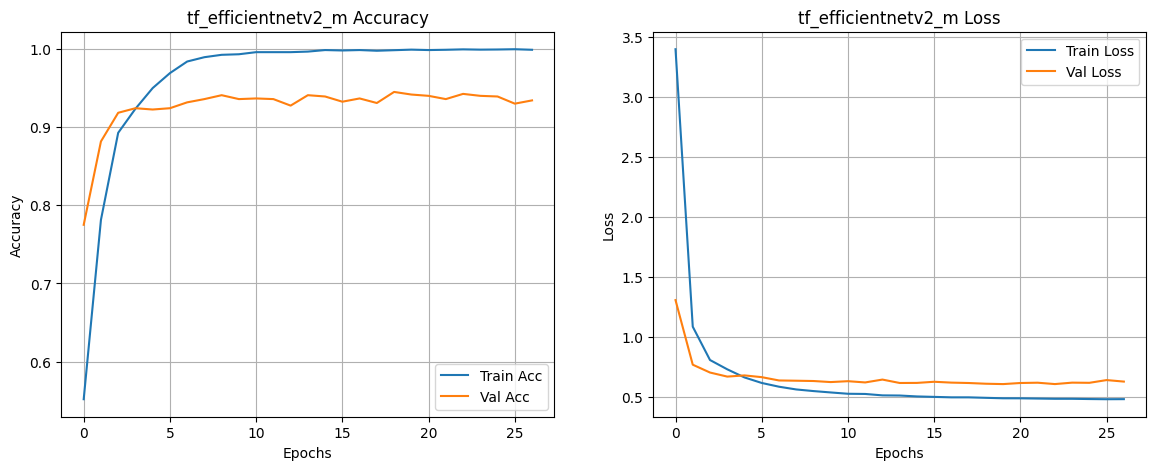

Grafikler kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\training_graph_tf_efficientnetv2_m_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.png


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title(f'{MODEL_NAME} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'{MODEL_NAME} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'training_graph_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Grafikler kaydedildi: {plot_path}")


TEST SETI DEGERLENDIRMESI

Siniflandirma Raporu:
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9539    0.9603    0.9571       151
dyed-resection-margins     0.9664    0.9536    0.9600       151
           esophagitis     0.8859    0.8742    0.8800       151
          normal-cecum     0.9494    0.9934    0.9709       151
        normal-pylorus     0.9869    1.0000    0.9934       151
         normal-z-line     0.8758    0.8874    0.8816       151
                polyps     0.9792    0.9338    0.9559       151
    ulcerative-colitis     0.9533    0.9470    0.9502       151

              accuracy                         0.9437      1208
             macro avg     0.9439    0.9437    0.9436      1208
          weighted avg     0.9439    0.9437    0.9436      1208

Macro F1: 0.9436
Class recall degerleri:
  dyed-lifted-polyps: 0.9603
  dyed-resection-margins: 0.9536
  esophagitis: 0.8742
  normal-cecum: 0.9934
  normal-pylorus: 1.0000
  norm

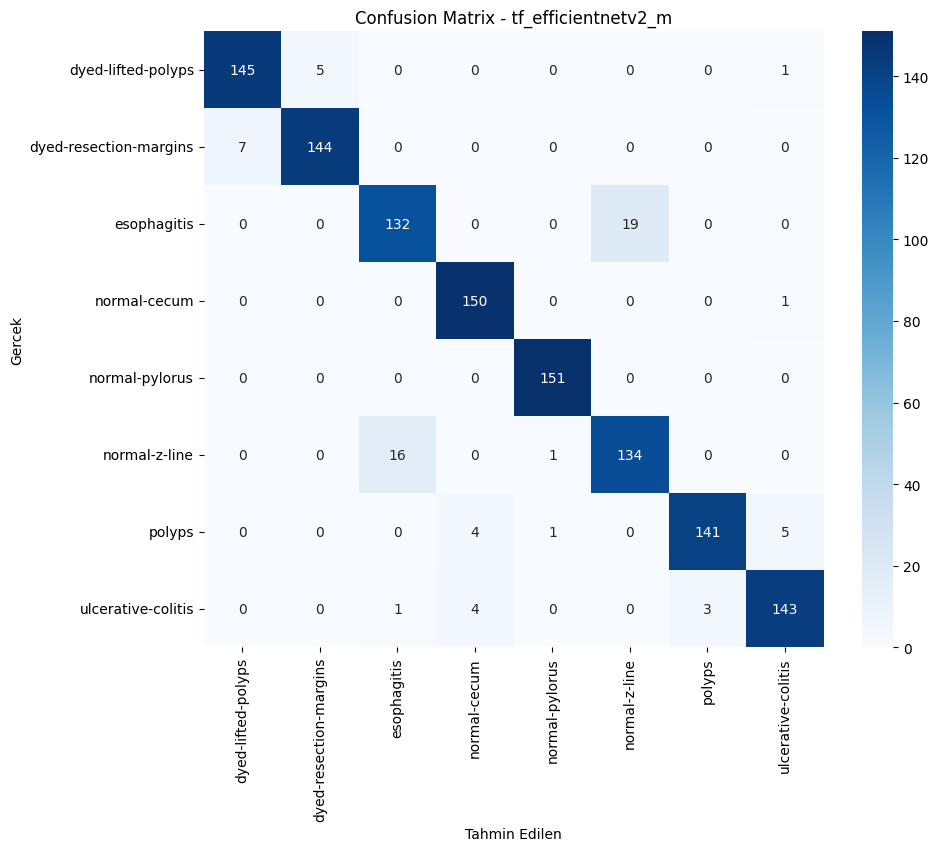

Confusion matrix kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\confusion_matrix_tf_efficientnetv2_m_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.png
esophagitis <-> normal-z-line toplam hata: 35
dyed-lifted-polyps <-> dyed-resection-margins toplam hata: 12
Ablation sonuclari kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\ablation_results_tf_efficientnetv2_m.csv
Son kayit:
                                                                                                run_name                                                  run_tag          model_name  batch_size  learning_rate  weight_decay  dropout_rate  label_smoothing  force_weighted_sampler  use_weighted_sampler  use_class_weighted_loss  early_stopping_patience  best_val_acc  best_val_loss  test_macro_f1  pair_err_esophagitis_normal_z_line  pair_err_dyed_lifted_vs_resection
EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_

In [ ]:
print("\nTEST SETI DEGERLENDIRMESI")

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\nSiniflandirma Raporu:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

macro_f1 = f1_score(y_true, y_pred, average='macro')
class_recalls = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))))
print(f"Macro F1: {macro_f1:.4f}")
print("Class recall degerleri:")
for class_name, rec in zip(class_names, class_recalls):
    print(f"  {class_name}: {rec:.4f}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
primary_report_path = os.path.join(OUTPUT_DIR, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')
fallback_report_dir = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'reports')
fallback_report_path = os.path.join(fallback_report_dir, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')

report_path = primary_report_path
try:
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
        f.write(f"\nMacro F1: {macro_f1:.6f}\n")
        f.write("Class Recall:\n")
        for class_name, rec in zip(class_names, class_recalls):
            f.write(f"{class_name}: {rec:.6f}\n")
except (FileNotFoundError, OSError):
    os.makedirs(fallback_report_dir, exist_ok=True)
    report_path = fallback_report_path
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
        f.write(f"\nMacro F1: {macro_f1:.6f}\n")
        f.write("Class Recall:\n")
        for class_name, rec in zip(class_names, class_recalls):
            f.write(f"{class_name}: {rec:.6f}\n")
    print("Uyari: Uzun yol nedeniyle rapor fallback klasorune kaydedildi.")
print(f"Classification report kaydedildi: {report_path}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gercek')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'confusion_matrix_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Confusion matrix kaydedildi: {plot_path}")

name_to_idx = {name: i for i, name in enumerate(class_names)}
pair_1_a = 'esophagitis'
pair_1_b = 'normal-z-line'
pair_2_a = 'dyed-lifted-polyps'
pair_2_b = 'dyed-resection-margins'

pair_1_err = None
pair_2_err = None
if pair_1_a in name_to_idx and pair_1_b in name_to_idx:
    i, j = name_to_idx[pair_1_a], name_to_idx[pair_1_b]
    pair_1_err = int(cm[i, j] + cm[j, i])
if pair_2_a in name_to_idx and pair_2_b in name_to_idx:
    i, j = name_to_idx[pair_2_a], name_to_idx[pair_2_b]
    pair_2_err = int(cm[i, j] + cm[j, i])

if pair_1_err is not None:
    print(f"{pair_1_a} <-> {pair_1_b} toplam hata: {pair_1_err}")
if pair_2_err is not None:
    print(f"{pair_2_a} <-> {pair_2_b} toplam hata: {pair_2_err}")

latest_metrics = {
    'run_name': RUN_NAME,
    'run_tag': RUN_TAG,
    'model_name': MODEL_NAME,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'dropout_rate': DROPOUT_RATE,
    'label_smoothing': LABEL_SMOOTHING,
    'force_weighted_sampler': FORCE_WEIGHTED_SAMPLER,
    'use_weighted_sampler': USE_WEIGHTED_SAMPLER,
    'use_class_weighted_loss': USE_CLASS_WEIGHTED_LOSS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'best_val_acc': float(max(history['val_acc'])) if 'history' in globals() else None,
    'best_val_loss': float(min(history['val_loss'])) if 'history' in globals() else None,
    'test_macro_f1': float(macro_f1),
    'pair_err_esophagitis_normal_z_line': pair_1_err,
    'pair_err_dyed_lifted_vs_resection': pair_2_err
}

ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

new_row_df = pd.DataFrame([latest_metrics])
if os.path.exists(ablation_csv_path):
    old_df = pd.read_csv(ablation_csv_path)
    if 'run_tag' in old_df.columns:
        old_df = old_df[old_df['run_tag'] != RUN_TAG]
    result_df = pd.concat([old_df, new_row_df], ignore_index=True)
else:
    result_df = new_row_df

result_df.to_csv(ablation_csv_path, index=False)
print(f"Ablation sonuclari kaydedildi: {ablation_csv_path}")
print("Son kayit:")
print(new_row_df.to_string(index=False))

In [ ]:
# --- ABLATION KARSILASTIRMA OZETI ---
ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

if not os.path.exists(ablation_csv_path):
    raise FileNotFoundError(f"Ablation CSV bulunamadi: {ablation_csv_path}")

df = pd.read_csv(ablation_csv_path).copy()
if df.empty:
    raise ValueError('Ablation CSV bos.')

numeric_cols = [
    'best_val_acc',
    'best_val_loss',
    'test_macro_f1',
    'pair_err_esophagitis_normal_z_line',
    'pair_err_dyed_lifted_vs_resection'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

if 'pair_err_esophagitis_normal_z_line' in df.columns and 'pair_err_dyed_lifted_vs_resection' in df.columns:
    df['critical_pair_error_total'] = (
        df['pair_err_esophagitis_normal_z_line'].fillna(0) +
        df['pair_err_dyed_lifted_vs_resection'].fillna(0)
    )
else:
    df['critical_pair_error_total'] = np.nan

sort_cols = []
ascending = []
if 'test_macro_f1' in df.columns:
    sort_cols.append('test_macro_f1')
    ascending.append(False)
if 'critical_pair_error_total' in df.columns:
    sort_cols.append('critical_pair_error_total')
    ascending.append(True)
if 'best_val_loss' in df.columns:
    sort_cols.append('best_val_loss')
    ascending.append(True)

if sort_cols:
    ranked_df = df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
else:
    ranked_df = df.copy()

display_cols = [
    'run_name', 'run_tag', 'test_macro_f1', 'best_val_acc', 'best_val_loss',
    'pair_err_esophagitis_normal_z_line', 'pair_err_dyed_lifted_vs_resection',
    'critical_pair_error_total', 'force_weighted_sampler', 'learning_rate', 'weight_decay'
]
display_cols = [c for c in display_cols if c in ranked_df.columns]

print(f"Toplam kayit: {len(ranked_df)}")
print('\nEn iyi 5 kosu:')
display(ranked_df[display_cols].head(5))

best_run = ranked_df.iloc[0]
print('\nSecilen en iyi kosu:')
for c in display_cols:
    print(f"{c}: {best_run[c]}")

Toplam kayit: 3

En iyi 5 kosu:


,run_name,run_tag,test_macro_f1,best_val_acc,best_val_loss,pair_err_esophagitis_normal_z_line,pair_err_dyed_lifted_vs_resection,critical_pair_error_total,force_weighted_sampler,learning_rate,weight_decay
0,EfficientNetV2_Medium_Baseline_MediumLarge_Run...,dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_aug...,0.943633,0.945000,0.609837,35,12,47,False,0.00015,0.0010
1,EfficientNetV2_Medium_Baseline_MediumLarge_Run...,dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_aug...,0.941988,0.939167,0.627918,38,15,53,False,0.00015,0.0010
2,EfficientNetV2_Medium_Baseline_MediumLarge_Run...,dropout02_ls10_wd0p0005_bs32_ep50_lr0p0002_smpOFF,0.928795,0.938333,0.625509,45,18,63,False,0.00020,0.0005



Secilen en iyi kosu:
run_name: EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
run_tag: dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
test_macro_f1: 0.9436334765406706
best_val_acc: 0.945
best_val_loss: 0.6098369495073954
pair_err_esophagitis_normal_z_line: 35
pair_err_dyed_lifted_vs_resection: 12
critical_pair_error_total: 47
force_weighted_sampler: False
learning_rate: 0.00015
weight_decay: 0.001
